# Linear Regression Using Neural Network

In [1]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Import Dataset
dataset = pd.read_csv('dataset/weatherHistory.csv')
dataset.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
# Check Dataset
print(dataset.columns)

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


In [4]:
# Feature Selection -> memilih atribut yang hanya kt perlukan dan buang yang tidak diperlukan

dataset = dataset.drop(['Formatted Date', 'Summary', 'Precip Type', 'Loud Cover', 'Daily Summary'], axis=1)

# axis -> ara operasi yang akan dilakukan pada dataframe
# 0 -> row
# 1 -> column

In [5]:
# Check Dataset 2 (apakah columnya udah dihapus atau belum)
print(dataset.columns)

Index(['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
       'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
       'Pressure (millibars)'],
      dtype='object')


In [6]:
# Menentukan feature yang akan menjadi target dan non target

# Non Target Features -> semua feature yang digunakan untuk menebak Humidity
non_target_features = dataset.drop(['Humidity'], axis=1)

# Target Feature -> feature yang ingin ditebak
target_features = dataset['Humidity']

In [7]:
# Split Data
# Ratio -> 80 (training) : 10 (testing) : 10 (validation)

x_train, x_temp, y_train, y_temp = train_test_split(non_target_features, target_features, test_size=0.2, random_state=19)

# Pembagian Testing and Validation
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=19)

In [8]:
# Standarisasi Data

# 1. Buat Scaler
scales = StandardScaler()

# 2. Standarisasi Data
# Training -> fit transform
x_train = scales.fit_transform(x_train)

# Testing and Validating -> transform
x_test = scales.transform(x_test)
x_val = scales.transform(x_val)

In [9]:
# Build Model

model = Sequential([
    Dense(32, activation="relu", input_dim= x_train.shape[1]),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

# Compile Model
model.compile(optimizer="adam", loss="mae", metrics=["mean_squared_error"])
# Optimizer -> algoritma yang membantu model memperbaiki kesalahan / bobotnya
# Loss Function -> seberapa jauh prediksi model dari target sebenarnya
# Metrics -> Memantau / mengukur performa dari model selama proses training + evaluasi

/opt/homebrew/Caskroom/miniforge/base/envs/ai-core/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-14 10:29:23.251975: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-14 10:29:23.252205: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-14 10:29:23.252209: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-14 10:29:23.252440: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-14 10:29:23.252457: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_

In [10]:
# Model Training

history = model.fit(x_train, y_train, epochs=100, batch_size=256, validation_data=(x_val, y_val))

Epoch 1/100


2026-09-14 10:29:23.942980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1685 - mean_squared_error: 0.0750 - val_loss: 0.1220 - val_mean_squared_error: 0.0238
Epoch 2/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1225 - mean_squared_error: 0.0239 - val_loss: 0.1158 - val_mean_squared_error: 0.0214
Epoch 3/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1342 - mean_squared_error: 0.0282 - val_loss: 0.1161 - val_mean_squared_error: 0.0215
Epoch 4/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1524 - mean_squared_error: 0.0375 - val_loss: 0.2052 - val_mean_squared_error: 0.0651
Epoch 5/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1632 - mean_squared_error: 0.0445 - val_loss: 0.1972 - val_mean_squared_error: 0.0560
Epoch 6/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1866 - mean_squared_error: 0.0568 - val_loss: 0.2665 - val_mean_squared_error: 0.1109
Epoch 7/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2049 - mean_squared_error: 0.0781 - val_loss: 0.

In [11]:
# Model Evaluation

loss, mse = model.evaluate(x_test, y_test)
print("Loss:", loss)
print("MSE:", mse)


302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5868 - mean_squared_error: 0.5266
Loss: 0.5867964625358582
MSE: 0.5266084671020508


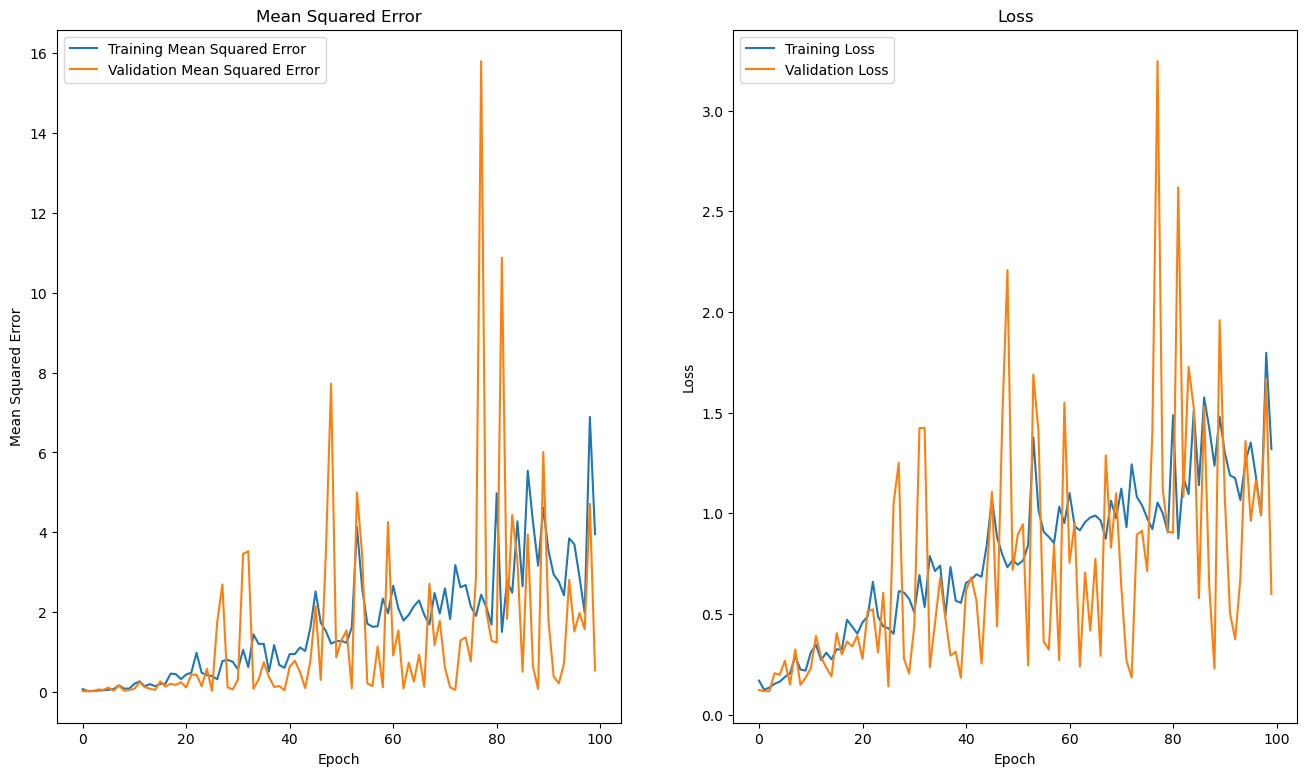

In [ ]:
# Evaluasi Menggunakan Plotting

plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)

# sebelah kiri -> mse
plt.plot(history.history['mean_squared_error'], label = "Training Mean Squared Error")
plt.plot(history.history['val_mean_squared_error'], label = "Validation Mean Squared Error")
plt.title("Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()

# sebelah kanan -> loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save hasilnya
# plt.savefig("Model_Evaluation.png")

# Show hasilnya
plt.show()

In [13]:
# Prediction Using Model

# 1. Buat list kosong -> prediction values, actual values
prediction_values = []
actual_values = []

# 2. Predict
predictions = model.predict(x_test[:5])
actual = y_test[:5].values

# 3. Masukkan hasil prediksi ke dalam list
for value in predictions:
  prediction_values.append(value[0])

# 4. Masukkan hasil aktual ke dalam list
for value in y_test:
  actual_values.append(value)

# 5. Print hasilnya
print("Actual                          Predicted")
print("==========================================")
for (predicted, actual) in zip(prediction_values, actual_values):
  print(f"{actual}                        {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Actual                          Predicted
0.8                        1.5760293006896973
1.0                        -0.02734518051147461
0.65                        1.4103074073791504
0.39                        -0.12771987915039062
0.41                        -0.3193058967590332
